#Cargar datos

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv("/content/sample_data/Heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         294 non-null    int64  
 1   sex         294 non-null    int64  
 2   cp          294 non-null    int64  
 3   trestbps    294 non-null    object 
 4   chol        294 non-null    object 
 5   fbs         294 non-null    object 
 6   restecg     294 non-null    object 
 7   thalach     294 non-null    object 
 8   exang       294 non-null    object 
 9   oldpeak     294 non-null    float64
 10  slope       294 non-null    object 
 11  ca          294 non-null    object 
 12  thal        294 non-null    object 
 13  num         294 non-null    int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 32.3+ KB


,age,sex,cp,oldpeak,num
count,294.000000,294.000000,294.000000,294.000000,294.000000
mean,47.826531,0.724490,2.982993,0.586054,0.360544
std,7.811812,0.447533,0.965117,0.908648,0.480977
min,28.000000,0.000000,1.000000,0.000000,0.000000
25%,42.000000,0.000000,2.000000,0.000000,0.000000
50%,49.000000,1.000000,3.000000,0.000000,0.000000
75%,54.000000,1.000000,4.000000,1.000000,1.000000
max,66.000000,1.000000,4.000000,5.000000,1.000000


In [ ]:
df.columns
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num       '],
      dtype='object')


In [ ]:
df.isin(['?']).sum()

,0
age,0
sex,0
cp,0
trestbps,1
chol,23
fbs,8
restecg,1
thalach,1
exang,1
oldpeak,0


In [ ]:
df = df.replace('?', np.nan)

In [ ]:
df = df.apply(pd.to_numeric)

In [ ]:
df = df.fillna(df.mean())

In [ ]:
media_age=df['age'].mean()
mediana_age=df['age'].median()
moda_age=df['age'].mode()
rango_age=df['age'].max()-df['age'].min()
varianza_age=df['age'].var()
desviacion_age=df['age'].std()

print("La media es: ", media_age)
print("La mediana es: ", mediana_age)
print("La moda es: ", moda_age)

print("El rango es: ", rango_age)
print("La varianza es: ", varianza_age)
print("La desciacion estandar es: ", desviacion_age)


La media es:  47.826530612244895
La mediana es:  49.0
La moda es:  0    54
Name: age, dtype: int64
El rango es:  38
La varianza es:  61.02441317824056
La desciacion estandar es:  7.811812413149752


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

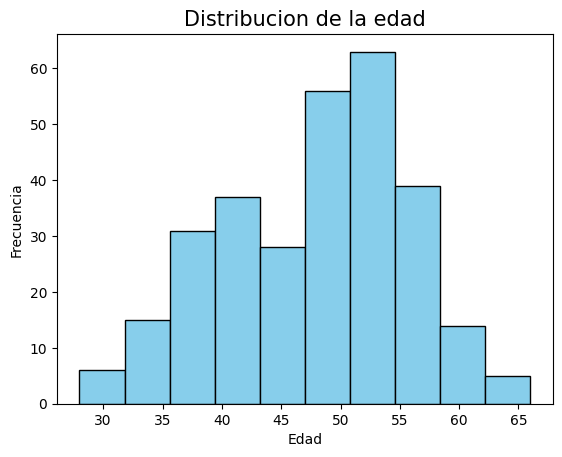

In [ ]:
plt.hist(df['age'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribucion de la edad', fontsize=15)
plt.xlabel('Edad', fontsize=10)
plt.ylabel('Frecuencia', fontsize=10)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

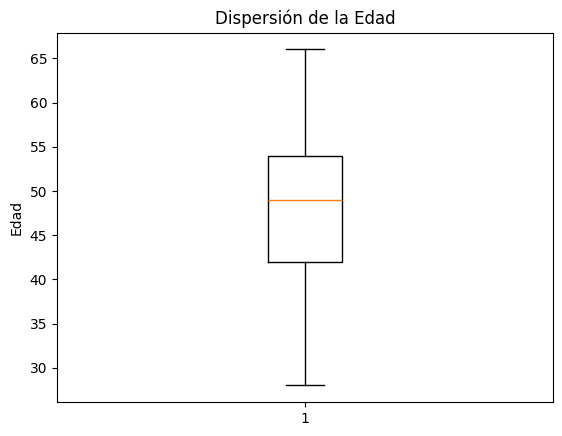

In [ ]:
plt.boxplot(df['age'])
plt.title("Dispersión de la Edad")
plt.ylabel("Edad")
plt

In [ ]:
media_thalach=df['thalach'].mean()
mediana_thalach=df['thalach'].median()
moda_thalach=df['thalach'].mode()
rango_thalach = df['thalach'].max() -  df['thalach'].min()
varianza_thalach = df['thalach'].var()
desviacion_thalach = df['thalach'].std()

print("La media es: ", media_thalach)
print("La mediana es: ", mediana_thalach)
print("La moda es: ", moda_thalach)

print("El rango es: ", rango_thalach)
print("La varianza es: ", varianza_thalach)
print("La desviacion estandar es: ", desviacion_thalach)

La media es:  139.1296928327645
La mediana es:  140.0
La moda es:  0    150.0
Name: thalach, dtype: float64
El rango es:  108.0
La varianza es:  554.5770364244196
La desviacion estandar es:  23.549459365862724


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

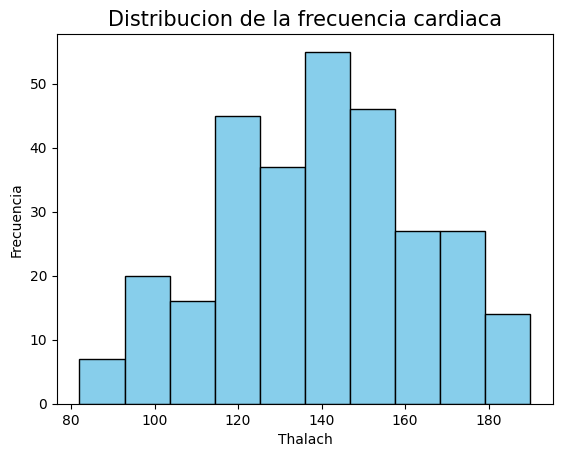

In [ ]:
plt.hist(df['thalach'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribucion de la frecuencia cardiaca', fontsize=15)
plt.xlabel('Thalach', fontsize=10)
plt.ylabel('Frecuencia', fontsize=10)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

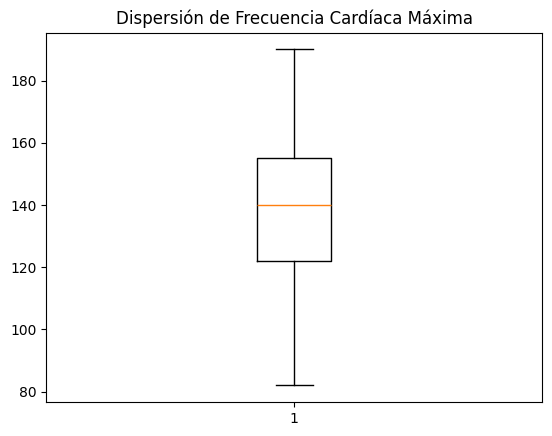

In [ ]:
plt.boxplot(df['thalach'])
plt.title("Dispersión de Frecuencia Cardíaca Máxima")
plt

In [ ]:
media_chol=df['chol'].mean()
mediana_chol=df['chol'].median()
moda_chol=df['chol'].mode()
rango_chol=df['chol'].max() -  df['chol'].min()
varianza_chol=df['chol'].var()
desviacion_chol=df['chol'].std()

print("La media es: ", media_chol)
print("La mediana es: ", mediana_chol)
print("La moda es: ", moda_chol)

print("El rango es: ", rango_chol)
print("La varianza es: ", varianza_chol)
print("La desviacion estandar es: ", desviacion_chol)


La media es:  250.84870848708488
La mediana es:  248.5
La moda es:  0    250.848708
Name: chol, dtype: float64
El rango es:  518.0
La varianza es:  4218.234802211504
La desviacion estandar es:  64.94793916831776


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

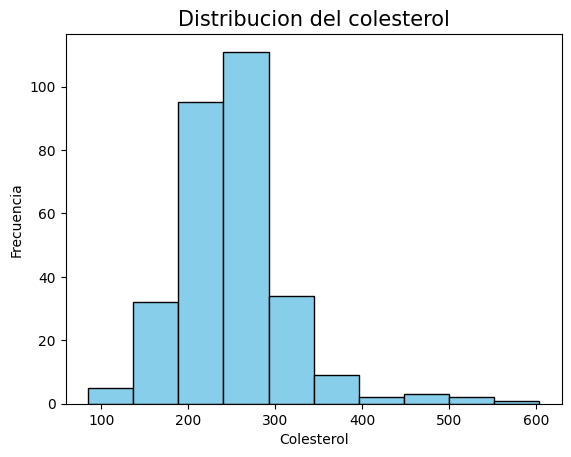

In [ ]:
plt.hist(df['chol'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribucion del colesterol', fontsize=15)
plt.xlabel('Colesterol', fontsize=10)
plt.ylabel('Frecuencia', fontsize=10)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

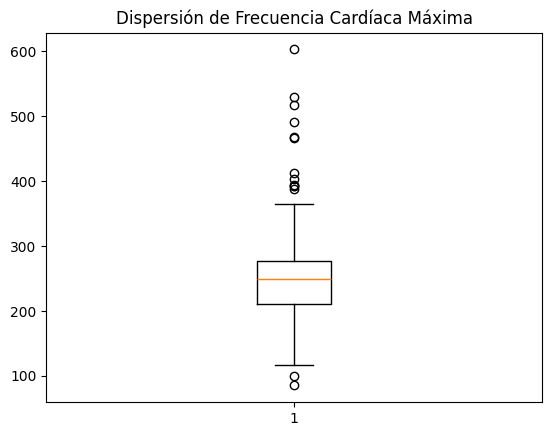

In [ ]:
plt.boxplot(df['chol'])
plt.title("Dispersión de Frecuencia Cardíaca Máxima")
plt

# Entrenamiento del modelo

In [ ]:
X = df.drop("num       ", axis=1)
y = df["num       "]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler() #Para que las variables esten en una misma escala

X_train = scaler.fit_transform(X_train)  #media de cada variable junto con su DE, aprende el escalado
X_test = scaler.transform(X_test) #aplica el escalado al test

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#Evaluacion del modelo

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred)) #reporte

Accuracy: 0.8983050847457628
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        38
           1       0.86      0.86      0.86        21

    accuracy                           0.90        59
   macro avg       0.89      0.89      0.89        59
weighted avg       0.90      0.90      0.90        59



In [ ]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7966101694915254


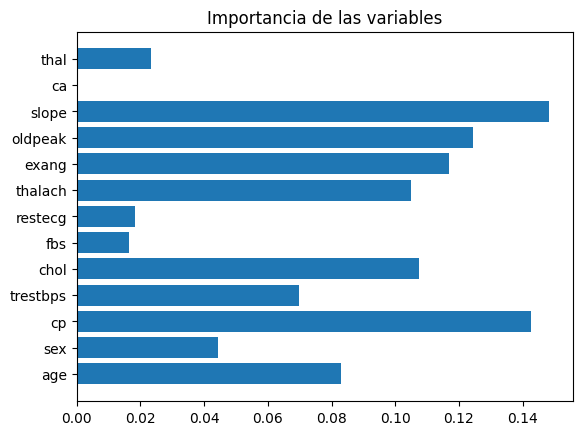

In [ ]:
importances = rf.feature_importances_

features = X.columns

plt.barh(features, importances)
plt.title("Importancia de las variables")
plt.show()

In [ ]:
nuevo = [[63,1,3,145,233,1,0,150,0,2.3,0,0,1]]

nuevo = scaler.transform(nuevo)

pred = rf.predict(nuevo)

print(pred)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[32  6]
 [ 6 15]]


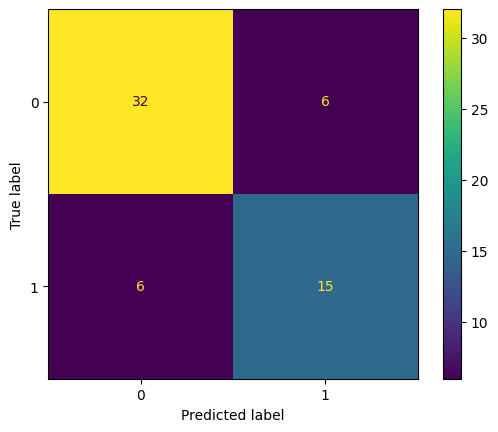

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()

In [ ]:
media_chol=df['chol'].mean()
mediana_chol=df['chol'].median()
moda_chol=df['chol'].mode()
rango_chol=df['chol'].max() -  df['chol'].min()
varianza_chol=df['chol'].var()
desviacion_chol=df['chol'].std()

print("La media es: ", media_chol)
print("La mediana es: ", mediana_chol)
print("La moda es: ", moda_chol)

print("El rango es: ", rango_chol)
print("La varianza es: ", varianza_chol)
print("La desviacion estandar es: ", desviacion_chol)


La media es:  250.84870848708488
La mediana es:  248.5
La moda es:  0    250.848708
Name: chol, dtype: float64
El rango es:  518.0
La varianza es:  4218.234802211504
La desviacion estandar es:  64.94793916831776


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

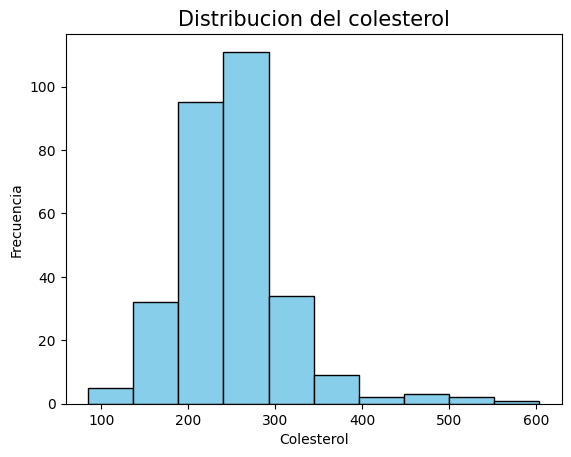

In [ ]:
plt.hist(df['chol'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribucion del colesterol', fontsize=15)
plt.xlabel('Colesterol', fontsize=10)
plt.ylabel('Frecuencia', fontsize=10)
plt


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

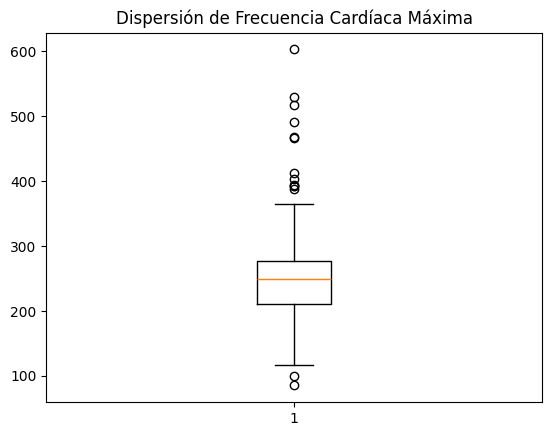

In [ ]:
plt.boxplot(df['chol'])
plt.title("Dispersión de Frecuencia Cardíaca Máxima")
plt